## PaddleOCR
PaddleOCR is an open-source OpticaL Character Regonition(OCR) toolkit developed by the PaddlePaddle team. 

### Main Features
- Multilingual Support: PaddleOCR supports 80 languages, making it versatile for various lingusitic applications. [See Multi-language model supported by PaddleOCR](https://paddlepaddle.github.io/PaddleOCR/main/en/ppocr/blog/multi_languages.html?h=language)
- Comprehensive Models: The toolkit offeres a range of models for text detection, recognition, and layout analysis, including flagship PP-OCR series
- Low-Code Development: With tools like paddleX, PaddleOCR factilates low-code developemt, enabling rapid deployment and customization of OCR models.

### References:
- [PaddlePaddle Official Gude](https://www.paddlepaddle.org.cn/en/install/quick?docurl=/documentation/docs/en/install/pip/macos-pip_en.html)
- [PaddleOCR Official Documentation](https://paddlepaddle.github.io/PaddleOCR/main/en/index.html)

In [59]:
import os
import cv2
from PIL import Image, ImageDraw
import numpy as np

from paddleocr import PaddleOCR

In [60]:
image_path = "./data/example-table.jpeg"
# Read the image as array
image_np = cv2.imread(image_path)
print(f"Shape of the image: {image.shape}")

# Display the image by converting the image_np to Image object
image = Image.fromarray(image_np)
image


AttributeError: shape

In [61]:

# Model will be downloaded at location ~/.paddleocr/
ocr = PaddleOCR()


[2025/03/03 00:09:23] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/sanjeev/.paddleocr/whl/det/ch/ch_PP-OCRv4_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/sanjeev/.paddleocr/whl/rec/ch/ch_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_n

### Text Detection Only
- `ocr.text_detector` takes image as array as image of ndim 3, which is quite inconsistent with `.ocr` method which only takes `Image` or `str` path, not the `np.ndarray`

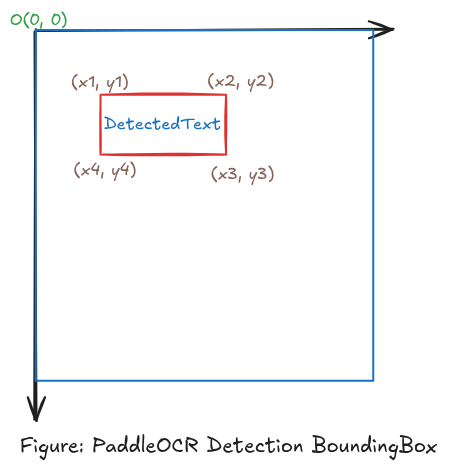

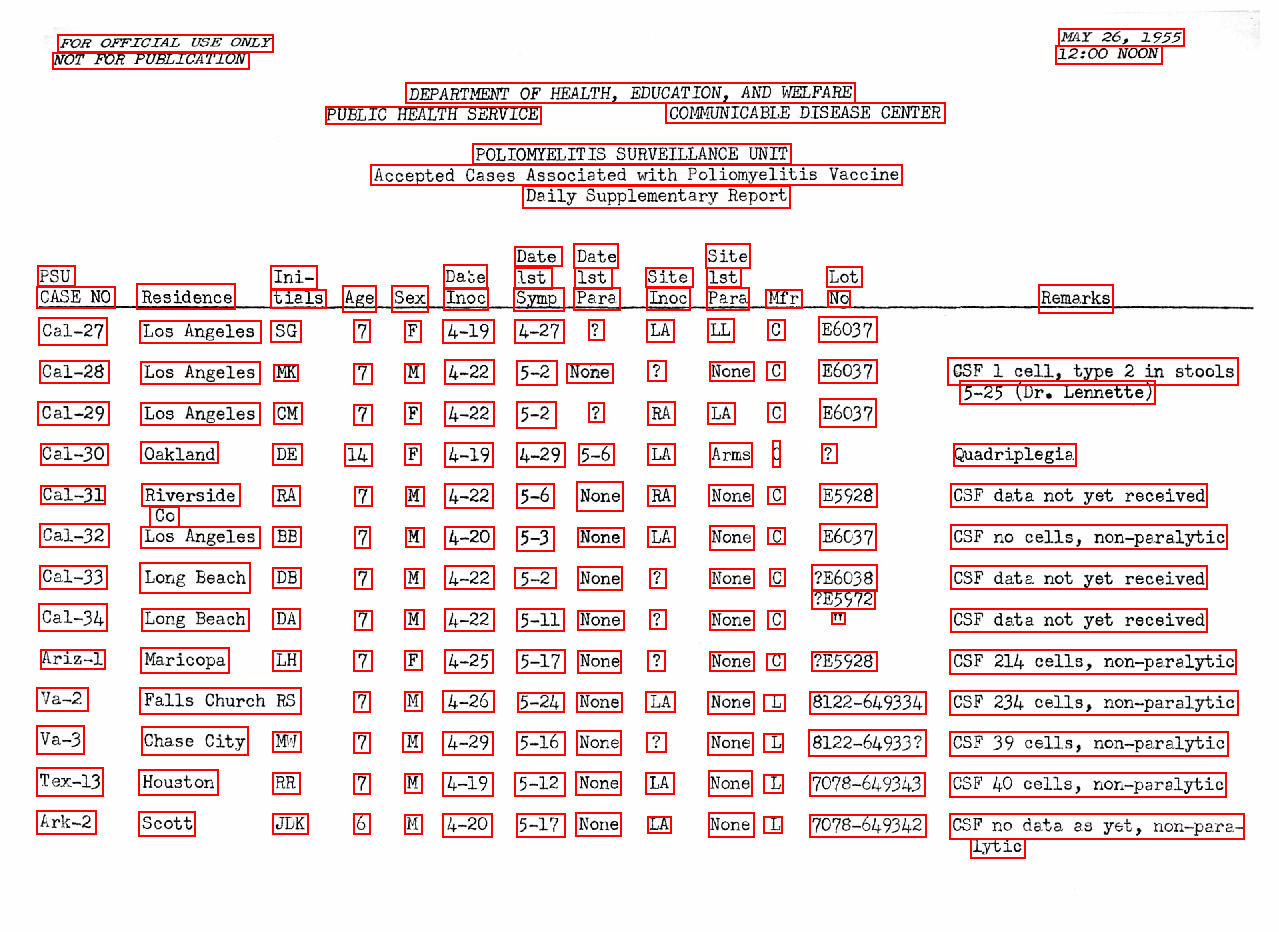

In [81]:
text_bboxes, _ = ocr.text_detector(image_np)

# Initiate new image object
image = Image.open(image_path).convert("RGB")
# Create a drawing context
draw = ImageDraw.Draw(image)

for bbox in text_bboxes:
    # bbox should be in the form of [(x1, y1), (x2, y2), (x3, y3), (x4, y4)]
    # where (x1, y1) is the top-left corner and (x3, y3) is the bottom-right corner
    # Reformat the bbox to (left, top, right, bottom)
    top_left = bbox[0]
    bottom_right = bbox[2]
    reformat_bbox = [top_left[0], top_left[1], bottom_right[0], bottom_right[1]]

    # Draw the bounding box on the image
    draw.rectangle(reformat_bbox, outline="red", width=2)

# Show the image
image

In [82]:
dir(ocr)

['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'args',
 'crop_image_res_index',
 'draw_crop_rec_res',
 'drop_score',
 'ocr',
 'page_num',
 'text_detector',
 'text_recognizer',
 'use_angle_cls']

In [95]:
# ocr.text_recognizer(image_np[:2])
# help(ocr.text_recognizer)
image_np[::,1].shape

(932, 3)

In [11]:
ocr.ocr(image_path)

[2025/03/02 23:47:44] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2025/03/02 23:47:45] ppocr DEBUG: dt_boxes num : 204, elapsed : 0.4389350414276123
[2025/03/02 23:47:57] ppocr DEBUG: rec_res num  : 204, elapsed : 12.516256093978882


[[[[[57.0, 34.0], [273.0, 34.0], [273.0, 52.0], [57.0, 52.0]],
   ('FOROFFICIALUSEONLY', 0.9964441657066345)],
  [[[1058.0, 28.0], [1184.0, 28.0], [1184.0, 46.0], [1058.0, 46.0]],
   ('MAY26,1955', 0.953377902507782)],
  [[[52.0, 52.0], [249.0, 52.0], [249.0, 69.0], [52.0, 69.0]],
   ('NOTFORPUBLICATION', 0.9974461793899536)],
  [[[1055.0, 45.0], [1162.0, 45.0], [1162.0, 64.0], [1055.0, 64.0]],
   ('12:00NOON', 0.8573257923126221)],
  [[[405.0, 82.0], [855.0, 81.0], [855.0, 103.0], [405.0, 105.0]],
   ('DEPARTMENT OF HEALTH,EDUCATION,AND WELFARE', 0.9651681780815125)],
  [[[325.0, 106.0], [541.0, 106.0], [541.0, 124.0], [325.0, 124.0]],
   ('PUBLIC HEALTH SERVICE', 0.9509817957878113)],
  [[[665.0, 102.0], [945.0, 101.0], [945.0, 123.0], [665.0, 124.0]],
   ('COMMUNICABLEDISEASE CENTER', 0.9791173934936523)],
  [[[472.0, 143.0], [791.0, 142.0], [791.0, 164.0], [472.0, 166.0]],
   ('POLIOMYELITISSURVEILLANCEUNIT', 0.9955403804779053)],
  [[[370.0, 164.0], [902.0, 163.0], [902.0, 185.0],